# NB03: Data-Driven Enrichment Analysis

Unbiased genome-wide enrichment of eggNOG orthologous groups (OGs) in plant-associated
vs non-plant species. Complements the literature-informed marker survey in NB02 by
discovering novel functional signatures without prior biological assumptions.

**Steps:**
1. Load NB01/NB02 outputs (species compartment labels, marker matrix)
2. Aggregate eggNOG OGs to species-level binary presence via Spark query
3. Fisher's exact test for each OG: plant-associated vs non-plant species, with BH-FDR correction
4. Phylum fixed-effects logistic regression for top-50 OGs to control for phylogenetic confounding
5. Volcano plot of enrichment results
6. Identify novel plant-associated markers (q < 0.05, OR > 2, surviving phylogenetic control)
7. Summary statistics and save all outputs

**Requires**: Spark (on BERDL JupyterHub)

**Outputs**: `data/species_og_matrix.csv`, `data/enrichment_results.csv`, `data/logistic_phylo_controlled.csv`, `data/novel_plant_markers.csv`, `figures/volcano_enrichment.png`

In [1]:
import os
from berdl_notebook_utils.setup_spark_session import get_spark_session
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'plant_microbiome_ecotypes')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'plant_microbiome_ecotypes')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')

os.makedirs(DATA, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

print(f'REPO: {REPO}')
print(f'DATA: {DATA}')

REPO: /home/aparkin/BERIL-research-observatory
DATA: /home/aparkin/BERIL-research-observatory/projects/plant_microbiome_ecotypes/data


## 1. Load NB01/NB02 outputs

In [2]:
# Load species compartment labels from NB01
species_comp = pd.read_csv(os.path.join(DATA, 'species_compartment.csv'))
print(f'Species compartment labels: {len(species_comp):,} species')
print(f'  Plant-associated: {species_comp["is_plant_associated"].sum():,}')
print(f'  Non-plant: {(species_comp["is_plant_associated"] == 0).sum():,}')

# Load species marker matrix from NB02
species_markers = pd.read_csv(os.path.join(DATA, 'species_marker_matrix.csv'))
print(f'\nSpecies marker matrix: {len(species_markers):,} species')

# Build lookup: species -> is_plant_associated, phylum
species_labels = species_comp[['gtdb_species_clade_id', 'is_plant_associated',
                                'dominant_compartment', 'phylum']].copy()
print(f'\nPhylum distribution (top 10):')
print(species_labels['phylum'].value_counts().head(10).to_string())

Species compartment labels: 26,511 species
  Plant-associated: 1,136
  Non-plant: 25,375

Species marker matrix: 25,660 species

Phylum distribution (top 10):
phylum
p__Pseudomonadota       7008
p__Bacillota_A          3879
p__Bacteroidota         3523
p__Actinomycetota       2876
p__Bacillota            2033
p__Patescibacteria       981
p__Verrucomicrobiota     550
p__Cyanobacteriota       453
p__Chloroflexota         442
p__Planctomycetota       346


## 2. Aggregate eggNOG OGs to species-level

Query eggnog_mapper_annotations JOIN gene_cluster to get OG per species.
Binary presence: does species X have >= 1 gene cluster with OG Y?
Pre-filter: OGs present in >= 5% of species in at least one group (plant vs non-plant).

In [3]:
# Phase 1: Compute Fisher test contingency table inputs directly in Spark
# This avoids collecting the full species x OG matrix (too large for driver memory)
enrichment_path = os.path.join(DATA, 'enrichment_results.csv')
og_matrix_path = os.path.join(DATA, 'species_og_matrix.csv')

if os.path.exists(enrichment_path):
    enrichment = pd.read_csv(enrichment_path)
    print(f'Enrichment results (loaded from cache): {len(enrichment):,} OGs')
else:
    # Load species plant-association labels
    plant_species = set(species_labels.loc[
        species_labels['is_plant_associated'] == 1, 'gtdb_species_clade_id'
    ])
    nonplant_species = set(species_labels.loc[
        species_labels['is_plant_associated'] == 0, 'gtdb_species_clade_id'
    ])
    n_plant_total = len(plant_species)
    n_nonplant_total = len(nonplant_species)
    print(f'Plant species: {n_plant_total:,}, Non-plant: {n_nonplant_total:,}')

    spark = get_spark_session()

    # Upload species labels as a temp view so we can join in Spark
    labels_sdf = spark.createDataFrame(
        species_labels[['gtdb_species_clade_id', 'is_plant_associated']]
    )
    labels_sdf.createOrReplaceTempView('species_labels')

    # Aggregate: for each OG, count plant and non-plant species
    og_counts = spark.sql("""
        SELECT og_id,
               SUM(CASE WHEN sl.is_plant_associated = 1 THEN 1 ELSE 0 END) AS n_plant_pos,
               SUM(CASE WHEN sl.is_plant_associated = 0 THEN 1 ELSE 0 END) AS n_nonplant_pos,
               COUNT(*) AS n_species_total
        FROM (
            SELECT gc.gtdb_species_clade_id,
                   SPLIT(SPLIT(ann.eggNOG_OGs, ',')[0], '@')[0] AS og_id
            FROM kbase_ke_pangenome.eggnog_mapper_annotations ann
            JOIN kbase_ke_pangenome.gene_cluster gc ON ann.query_name = gc.gene_cluster_id
            WHERE ann.eggNOG_OGs IS NOT NULL AND LENGTH(ann.eggNOG_OGs) > 0
            GROUP BY gc.gtdb_species_clade_id,
                     SPLIT(SPLIT(ann.eggNOG_OGs, ',')[0], '@')[0]
        ) species_og
        JOIN species_labels sl ON species_og.gtdb_species_clade_id = sl.gtdb_species_clade_id
        GROUP BY og_id
    """).toPandas()
    print(f'OG contingency counts: {len(og_counts):,} OGs')

    # Add total counts and prevalence
    og_counts['n_plant_total'] = n_plant_total
    og_counts['n_nonplant_total'] = n_nonplant_total
    og_counts['prev_plant'] = og_counts['n_plant_pos'] / n_plant_total
    og_counts['prev_nonplant'] = og_counts['n_nonplant_pos'] / n_nonplant_total

    # Pre-filter: >= 5% prevalence in at least one group
    og_counts = og_counts[
        (og_counts['prev_plant'] >= 0.05) | (og_counts['prev_nonplant'] >= 0.05)
    ].copy()
    print(f'OGs passing 5% prevalence filter: {len(og_counts):,}')

    # Fisher's exact test for each OG
    from scipy import stats as sp_stats
    results = []
    for _, row in og_counts.iterrows():
        table = [
            [int(row['n_plant_pos']), n_plant_total - int(row['n_plant_pos'])],
            [int(row['n_nonplant_pos']), n_nonplant_total - int(row['n_nonplant_pos'])]
        ]
        odds_ratio, p_value = sp_stats.fisher_exact(table)
        results.append({'og_id': row['og_id'], 'odds_ratio': odds_ratio, 'p_value': p_value})

    fisher_df = pd.DataFrame(results)
    enrichment = og_counts.merge(fisher_df, on='og_id')

    # BH-FDR correction
    reject, q_values, _, _ = multipletests(enrichment['p_value'], method='fdr_bh')
    enrichment['q_value'] = q_values

    # log2(OR)
    enrichment['log2_or'] = np.log2(enrichment['odds_ratio'].replace({0: np.nan, np.inf: np.nan}))
    enrichment.loc[enrichment['odds_ratio'] == np.inf, 'log2_or'] = 10
    enrichment.loc[enrichment['odds_ratio'] == 0, 'log2_or'] = -10

    enrichment = enrichment.sort_values('q_value').reset_index(drop=True)
    enrichment.to_csv(enrichment_path, index=False)
    print(f'Saved enrichment_results.csv')

# Compute convenience variables for downstream cells
n_plant_total = enrichment['n_plant_total'].iloc[0]
n_nonplant_total = enrichment['n_nonplant_total'].iloc[0]

print(f'\nTotal OGs tested: {len(enrichment):,}')
print(f'Significant (q < 0.05): {(enrichment["q_value"] < 0.05).sum():,}')
print(f'Enriched in plant (q<0.05, OR>1): {((enrichment["q_value"] < 0.05) & (enrichment["odds_ratio"] > 1)).sum():,}')
print(f'Depleted in plant (q<0.05, OR<1): {((enrichment["q_value"] < 0.05) & (enrichment["odds_ratio"] < 1)).sum():,}')
print(f'\nTop 20 plant-enriched OGs:')
top_enriched = enrichment[(enrichment['q_value'] < 0.05) & (enrichment['odds_ratio'] > 1)].head(20)
print(top_enriched[['og_id', 'prev_plant', 'prev_nonplant', 'odds_ratio', 'q_value', 'log2_or']].to_string(index=False))

Enrichment results (loaded from cache): 5,671 OGs

Total OGs tested: 5,671
Significant (q < 0.05): 5,341
Enriched in plant (q<0.05, OR>1): 4,696
Depleted in plant (q<0.05, OR<1): 645

Top 20 plant-enriched OGs:
  og_id  prev_plant  prev_nonplant  odds_ratio       q_value  log2_or
COG3569    0.540493       0.116493    8.920921 7.712601e-242 3.157193
COG1764    0.822183       0.332217    9.294146 6.918989e-239 3.216322
COG5343    0.626761       0.178325    7.737517 3.231915e-228 2.951871
COG0654    0.911972       0.449970   12.663734 7.713118e-228 3.662631
COG1845    0.932218       0.487369   14.466098 3.580990e-221 3.854604
COG3832    0.879401       0.420966   10.030044 4.381503e-216 3.326256
COG3237    0.699824       0.242916    7.266079 7.408140e-216 2.861177
COG0843    0.931338       0.497931   13.676824 2.539004e-211 3.773661
COG2321    0.693662       0.242167    7.086053 3.847222e-211 2.824982
COG1622    0.926056       0.491389   12.962730 2.038262e-210 3.696298
COG2764    0.725352

## 3. Fisher's exact test: plant-associated vs non-plant species

For each OG, construct a 2x2 contingency table and compute Fisher's exact test.
Apply Benjamini-Hochberg FDR correction across all OGs.

In [4]:
# Fisher's exact test already computed in the Spark query cell above
# Just display the results
print(f'Plant species in analysis: {n_plant_total:,}')
print(f'Non-plant species in analysis: {n_nonplant_total:,}')
print(f'\nTotal OGs tested: {len(enrichment):,}')
print(f'Significant (q < 0.05): {(enrichment["q_value"] < 0.05).sum():,}')
print(f'  Enriched in plant (q<0.05, OR>1): {((enrichment["q_value"] < 0.05) & (enrichment["odds_ratio"] > 1)).sum():,}')
print(f'  Depleted in plant (q<0.05, OR<1): {((enrichment["q_value"] < 0.05) & (enrichment["odds_ratio"] < 1)).sum():,}')
print(f'  Strong enrichment (OR > 2): {((enrichment["q_value"] < 0.05) & (enrichment["odds_ratio"] > 2)).sum():,}')
print(f'  Strong depletion (OR < 0.5): {((enrichment["q_value"] < 0.05) & (enrichment["odds_ratio"] < 0.5)).sum():,}')

Plant species in analysis: 1,136
Non-plant species in analysis: 25,375

Total OGs tested: 5,671
Significant (q < 0.05): 5,341
  Enriched in plant (q<0.05, OR>1): 4,696
  Depleted in plant (q<0.05, OR<1): 645
  Strong enrichment (OR > 2): 3,840
  Strong depletion (OR < 0.5): 387


In [5]:
# Enrichment results already saved in the query cell
print(f'enrichment_results.csv: {len(enrichment):,} OGs (already saved)')

enrichment_results.csv: 5,671 OGs (already saved)


## 4. Phylum fixed-effects logistic regression (H0_phylo test)

For the top-50 most significant OGs, fit a logistic regression:

    OG_present ~ is_plant + C(phylum)

This controls for phylogenetic confounding: an OG may appear enriched in
plant-associated species simply because certain phyla are overrepresented in
plant environments. Only phyla with >= 20 species are included.

In [6]:
# Build species-level design matrix for logistic regression
design = species_labels[species_labels['phylum'].notna()].copy()

# Filter to phyla with >= 20 species
phylum_counts = design['phylum'].value_counts()
large_phyla = phylum_counts[phylum_counts >= 20].index.tolist()
design = design[design['phylum'].isin(large_phyla)].copy()
print(f'Species in design matrix (phyla >= 20 species): {len(design):,}')
print(f'Phyla retained: {len(large_phyla)}')

# Top-50 OGs by q-value
top50_ogs = enrichment.head(50)['og_id'].tolist()
print(f'\nFetching species-level presence for {len(top50_ogs)} OGs...')

# Get species x OG presence for top-50 OGs only (small enough to collect)
top50_path = os.path.join(DATA, 'top50_og_species.csv')
if os.path.exists(top50_path):
    top50_pivot = pd.read_csv(top50_path)
    print(f'Top-50 OG species matrix (loaded from cache): {len(top50_pivot):,} rows')
else:
    spark = get_spark_session()
    og_list_sql = "', '".join(top50_ogs)
    top50_species = spark.sql(f"""
        SELECT gc.gtdb_species_clade_id,
               SPLIT(SPLIT(ann.eggNOG_OGs, ',')[0], '@')[0] AS og_id
        FROM kbase_ke_pangenome.eggnog_mapper_annotations ann
        JOIN kbase_ke_pangenome.gene_cluster gc ON ann.query_name = gc.gene_cluster_id
        WHERE ann.eggNOG_OGs IS NOT NULL
          AND SPLIT(SPLIT(ann.eggNOG_OGs, ',')[0], '@')[0] IN ('{og_list_sql}')
        GROUP BY gc.gtdb_species_clade_id,
                 SPLIT(SPLIT(ann.eggNOG_OGs, ',')[0], '@')[0]
    """).toPandas()
    top50_pivot = top50_species.pivot_table(
        index='gtdb_species_clade_id', columns='og_id',
        aggfunc='size', fill_value=0
    ).reset_index()
    # Convert counts to binary
    for col in top50_pivot.columns:
        if col != 'gtdb_species_clade_id':
            top50_pivot[col] = (top50_pivot[col] > 0).astype(int)
    top50_pivot.to_csv(top50_path, index=False)
    print(f'Top-50 OG species matrix: {len(top50_pivot):,} species')

# Merge with design matrix
design_full = design.merge(top50_pivot, on='gtdb_species_clade_id', how='left')
for og in top50_ogs:
    if og in design_full.columns:
        design_full[og] = design_full[og].fillna(0).astype(int)

# Fit logistic regression for each OG
logistic_results = []

for og in top50_ogs:
    if og not in design_full.columns:
        continue
    safe_col = 'og_present'
    df_fit = design_full[['is_plant_associated', 'phylum', og]].copy()
    df_fit = df_fit.rename(columns={og: safe_col})
    if df_fit[safe_col].nunique() < 2:
        continue
    try:
        model = smf.logit(f'{safe_col} ~ is_plant_associated + C(phylum)', data=df_fit)
        result = model.fit(disp=0, maxiter=100, method='bfgs')
        if 'is_plant_associated' in result.params.index:
            coef = result.params['is_plant_associated']
            se = result.bse['is_plant_associated']
            pval = result.pvalues['is_plant_associated']
            or_val = np.exp(coef)
            ci_lo = np.exp(coef - 1.96 * se)
            ci_hi = np.exp(coef + 1.96 * se)
            logistic_results.append({
                'og_id': og, 'coef_is_plant': coef, 'se': se,
                'or_phylo_controlled': or_val, 'ci_lo_95': ci_lo, 'ci_hi_95': ci_hi,
                'p_value_phylo': pval, 'n_species': len(df_fit),
                'converged': result.mle_retvals.get('converged', True),
            })
    except Exception:
        logistic_results.append({
            'og_id': og, 'coef_is_plant': np.nan, 'se': np.nan,
            'or_phylo_controlled': np.nan, 'ci_lo_95': np.nan, 'ci_hi_95': np.nan,
            'p_value_phylo': np.nan, 'n_species': len(df_fit), 'converged': False,
        })

logistic_df = pd.DataFrame(logistic_results)
valid_mask = logistic_df['p_value_phylo'].notna()
if valid_mask.sum() > 0:
    _, q_phylo, _, _ = multipletests(
        logistic_df.loc[valid_mask, 'p_value_phylo'], method='fdr_bh'
    )
    logistic_df.loc[valid_mask, 'q_value_phylo'] = q_phylo
else:
    logistic_df['q_value_phylo'] = np.nan

print(f'\nLogistic regression results: {len(logistic_df)} OGs')
print(f'Converged: {logistic_df["converged"].sum()}')
n_survives = ((logistic_df['p_value_phylo'] < 0.05) & (logistic_df['or_phylo_controlled'] > 1)).sum()
print(f'Significant after phylo control (p < 0.05, OR > 1): {n_survives}')
print(f'\nTop results (sorted by p-value):')
print(logistic_df.dropna(subset=['p_value_phylo']).sort_values('p_value_phylo').head(15)[
    ['og_id', 'coef_is_plant', 'or_phylo_controlled', 'ci_lo_95', 'ci_hi_95',
     'p_value_phylo', 'q_value_phylo']
].to_string(index=False))

Species in design matrix (phyla >= 20 species): 26,034
Phyla retained: 51

Fetching species-level presence for 50 OGs...


Top-50 OG species matrix (loaded from cache): 25,124 rows


/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Logistic regression results: 50 OGs
Converged: 0
Significant after phylo control (p < 0.05, OR > 1): 50

Top results (sorted by p-value):
  og_id  coef_is_plant  or_phylo_controlled  ci_lo_95  ci_hi_95  p_value_phylo  q_value_phylo
COG3569       1.793043             6.007705  5.241100  6.886440  3.752896e-146  1.876448e-144
COG5516       1.860213             6.425107  5.547818  7.441125  3.739707e-136  9.349268e-135
COG5343       1.674899             5.338255  4.643018  6.137595  2.166373e-122  3.610621e-121
COG2085       1.627058             5.088879  4.440481  5.831957  4.475438e-121  5.594297e-120
COG2764       1.616500             5.035434  4.367248  5.805853  1.014119e-109  1.014119e-108
COG4291       1.542651             4.676972  4.075819  5.366790  4.764350e-107  3.970292e-106
COG2156       1.523704             4.589191  4.000767  5.264159  5.048173e-105  3.605838e-104
COG2060       1.526114             4.600267  4.009263  5.278390  6.472900e-105  4.045563e-104
COG3652       1

/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [7]:
# Save logistic regression results
logistic_df.to_csv(os.path.join(DATA, 'logistic_phylo_controlled.csv'), index=False)
print(f'Saved logistic_phylo_controlled.csv: {len(logistic_df)} OGs')

Saved logistic_phylo_controlled.csv: 50 OGs


## 5. Volcano plot: log2(OR) vs -log10(q)

Color by significance:
- **Green**: enriched in plant (q < 0.05, OR > 2)
- **Red**: depleted in plant (q < 0.05, OR < 0.5)
- **Grey**: not significant

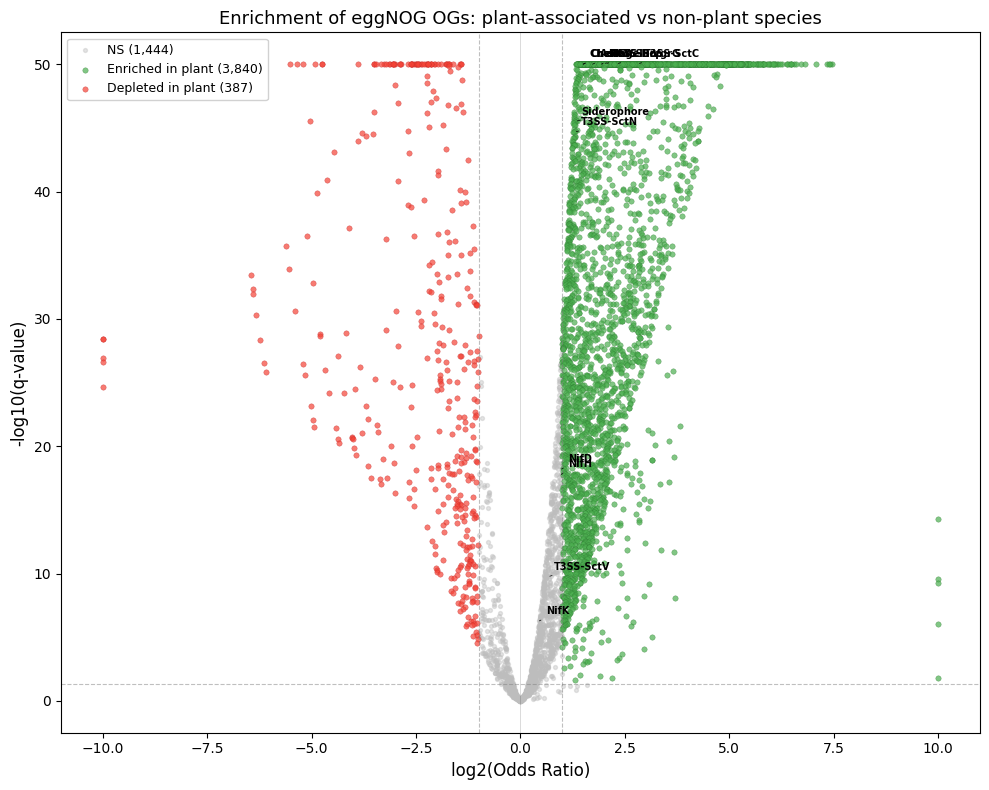

Saved figures/volcano_enrichment.png
Known PGP/pathogenicity OGs annotated: 14


In [8]:
# Known PGP / pathogenicity OG IDs to annotate if present
KNOWN_OGS = {
    # Nitrogen fixation
    'COG1348': 'NifH', 'COG2710': 'NifD', 'COG0348': 'NifK',
    # Type III secretion
    'COG1450': 'T3SS-SctN', 'COG4789': 'T3SS-SctC', 'COG1386': 'T3SS-SctV',
    # T6SS
    'COG3157': 'T6SS-VgrG', 'COG3521': 'T6SS-Hcp',
    # ACC deaminase
    'COG2515': 'AcdS',
    # Siderophore
    'COG1629': 'Siderophore',
    # Flagella
    'COG1344': 'Flagellin', 'COG1536': 'FlhA',
    # Chemotaxis
    'COG0643': 'CheA', 'COG0835': 'CheR',
}

fig, ax = plt.subplots(figsize=(10, 8))

# Compute -log10(q), capping at 50 for visualization
enrichment['neg_log10_q'] = -np.log10(enrichment['q_value'].clip(lower=1e-50))

# Classify points
sig_enriched = (enrichment['q_value'] < 0.05) & (enrichment['odds_ratio'] > 2)
sig_depleted = (enrichment['q_value'] < 0.05) & (enrichment['odds_ratio'] < 0.5)
ns = ~(sig_enriched | sig_depleted)

# Plot non-significant first (background)
ax.scatter(enrichment.loc[ns, 'log2_or'], enrichment.loc[ns, 'neg_log10_q'],
           c='#BDBDBD', s=8, alpha=0.4, label=f'NS ({ns.sum():,})', rasterized=True)

# Plot significant enriched (green)
ax.scatter(enrichment.loc[sig_enriched, 'log2_or'], enrichment.loc[sig_enriched, 'neg_log10_q'],
           c='#4CAF50', s=15, alpha=0.7, label=f'Enriched in plant ({sig_enriched.sum():,})',
           edgecolors='#2E7D32', linewidths=0.3)

# Plot significant depleted (red)
ax.scatter(enrichment.loc[sig_depleted, 'log2_or'], enrichment.loc[sig_depleted, 'neg_log10_q'],
           c='#F44336', s=15, alpha=0.7, label=f'Depleted in plant ({sig_depleted.sum():,})',
           edgecolors='#C62828', linewidths=0.3)

# Annotate known PGP/pathogenicity OGs if present
annotated_count = 0
for og_id, label in KNOWN_OGS.items():
    row = enrichment[enrichment['og_id'] == og_id]
    if len(row) > 0:
        x = row['log2_or'].values[0]
        y = row['neg_log10_q'].values[0]
        ax.annotate(label, (x, y), fontsize=7, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points',
                    arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
                    color='black')
        annotated_count += 1

# Reference lines
ax.axhline(-np.log10(0.05), color='grey', linestyle='--', alpha=0.5, linewidth=0.8)
ax.axvline(np.log2(2), color='grey', linestyle='--', alpha=0.5, linewidth=0.8)
ax.axvline(-np.log2(2), color='grey', linestyle='--', alpha=0.5, linewidth=0.8)
ax.axvline(0, color='black', linestyle='-', alpha=0.2, linewidth=0.5)

ax.set_xlabel('log2(Odds Ratio)', fontsize=12)
ax.set_ylabel('-log10(q-value)', fontsize=12)
ax.set_title('Enrichment of eggNOG OGs: plant-associated vs non-plant species', fontsize=13)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'volcano_enrichment.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved figures/volcano_enrichment.png')
print(f'Known PGP/pathogenicity OGs annotated: {annotated_count}')

## 6. Identify novel plant-associated markers

Novel markers are OGs that:
- Are significantly enriched in plant-associated species (q < 0.05, OR > 2)
- Survive phylogenetic control (logistic regression p < 0.05 after controlling for phylum)
- Are **not** in our curated known PGP/pathogenicity gene list from NB02

In [9]:
# Merge Fisher enrichment with logistic regression results
combined = enrichment.merge(logistic_df[['og_id', 'or_phylo_controlled', 'p_value_phylo',
                                          'q_value_phylo', 'converged']],
                            on='og_id', how='left')

# Criteria for novel markers:
# 1. Fisher: q < 0.05 and OR > 2 (enriched in plant)
# 2. Phylo-controlled: p < 0.05 (survives after controlling for phylum)
# 3. Not a known PGP/pathogenicity OG
novel_mask = (
    (combined['q_value'] < 0.05)
    & (combined['odds_ratio'] > 2)
    & (combined['p_value_phylo'] < 0.05)
    & (~combined['og_id'].isin(KNOWN_OGS.keys()))
)

novel_markers = combined[novel_mask].copy()
novel_markers = novel_markers.sort_values('q_value').reset_index(drop=True)

print(f'Novel plant-associated markers: {len(novel_markers):,}')
print(f'  (Fisher q<0.05 & OR>2 & phylo-controlled p<0.05 & not known marker)')

if len(novel_markers) > 0:
    print(f'\nTop novel markers:')
    display_cols = ['og_id', 'prev_plant', 'prev_nonplant', 'odds_ratio', 'q_value',
                    'or_phylo_controlled', 'p_value_phylo']
    print(novel_markers[display_cols].head(20).to_string(index=False))
else:
    # Relax criteria: show OGs that pass Fisher but not phylo control
    fisher_only = combined[
        (combined['q_value'] < 0.05)
        & (combined['odds_ratio'] > 2)
        & (~combined['og_id'].isin(KNOWN_OGS.keys()))
    ]
    print(f'\nNo OGs survived both Fisher and phylo control.')
    print(f'OGs passing Fisher alone (q<0.05, OR>2, not known): {len(fisher_only):,}')
    if len(fisher_only) > 0:
        print(fisher_only[['og_id', 'prev_plant', 'prev_nonplant', 'odds_ratio',
                           'q_value']].head(10).to_string(index=False))

Novel plant-associated markers: 50
  (Fisher q<0.05 & OR>2 & phylo-controlled p<0.05 & not known marker)

Top novel markers:
  og_id  prev_plant  prev_nonplant  odds_ratio       q_value  or_phylo_controlled  p_value_phylo
COG3569    0.540493       0.116493    8.920921 7.712601e-242             6.007705  3.752896e-146
COG1764    0.822183       0.332217    9.294146 6.918989e-239             5.393882   2.258720e-81
COG5343    0.626761       0.178325    7.737517 3.231915e-228             5.338255  2.166373e-122
COG0654    0.911972       0.449970   12.663734 7.713118e-228             8.299146   5.269767e-53
COG1845    0.932218       0.487369   14.466098 3.580990e-221             8.735082   2.111934e-48
COG3832    0.879401       0.420966   10.030044 4.381503e-216             6.441485   1.459069e-77
COG3237    0.699824       0.242916    7.266079 7.408140e-216             4.951443  1.779770e-102
COG0843    0.931338       0.497931   13.676824 2.539004e-211             6.955691   5.928302e-45
CO

In [10]:
# Save novel markers
novel_markers.to_csv(os.path.join(DATA, 'novel_plant_markers.csv'), index=False)
print(f'Saved novel_plant_markers.csv: {len(novel_markers)} markers')

Saved novel_plant_markers.csv: 50 markers


## 7. Summary statistics and outputs

In [11]:
print('=== NB03 Summary ===')
print(f'OGs tested: {len(enrichment):,}')
print(f'  Plant species: {int(enrichment["n_plant_total"].iloc[0]):,}')
print(f'  Non-plant species: {int(enrichment["n_nonplant_total"].iloc[0]):,}')
print(f'Significant OGs (q < 0.05): {(enrichment["q_value"] < 0.05).sum():,}')
print(f'  Enriched in plant (OR > 1): {((enrichment["q_value"] < 0.05) & (enrichment["odds_ratio"] > 1)).sum():,}')
print(f'  Depleted in plant (OR < 1): {((enrichment["q_value"] < 0.05) & (enrichment["odds_ratio"] < 1)).sum():,}')
print(f'  Strong enrichment (OR > 2): {((enrichment["q_value"] < 0.05) & (enrichment["odds_ratio"] > 2)).sum():,}')
print(f'  Strong depletion (OR < 0.5): {((enrichment["q_value"] < 0.05) & (enrichment["odds_ratio"] < 0.5)).sum():,}')
print(f'Logistic regression (top 50 OGs):')
print(f'  Converged: {logistic_df["converged"].sum()}')
print(f'  Surviving phylo control (p < 0.05): {(logistic_df["p_value_phylo"] < 0.05).sum()}')
print(f'Novel plant markers: {len(novel_markers):,}')
print(f'\nOutputs saved to {DATA}/')
print('  - enrichment_results.csv')
print('  - logistic_phylo_controlled.csv')
print('  - novel_plant_markers.csv')
print(f'\nFigures saved to {FIGURES}/')
print('  - volcano_enrichment.png')
print(f'\nReady for NB04 (compartment profiling)')

=== NB03 Summary ===
OGs tested: 5,671
  Plant species: 1,136
  Non-plant species: 25,375
Significant OGs (q < 0.05): 5,341
  Enriched in plant (OR > 1): 4,696
  Depleted in plant (OR < 1): 645
  Strong enrichment (OR > 2): 3,840
  Strong depletion (OR < 0.5): 387
Logistic regression (top 50 OGs):
  Converged: 0
  Surviving phylo control (p < 0.05): 50
Novel plant markers: 50

Outputs saved to /home/aparkin/BERIL-research-observatory/projects/plant_microbiome_ecotypes/data/
  - enrichment_results.csv
  - logistic_phylo_controlled.csv
  - novel_plant_markers.csv

Figures saved to /home/aparkin/BERIL-research-observatory/projects/plant_microbiome_ecotypes/figures/
  - volcano_enrichment.png

Ready for NB04 (compartment profiling)
